## AI Community Africa Capstone ML Project

# Residential Property Price Predictor Using Machine Learning

Goal: Develop a supervised machine learning regression model to estimate house prices based on significant property attributes.

### Tools applied
**VS code**: integrated development environment for writing and structuring the project.

**Jupyter notebook**: interactive interface for executing code segments and viewing results.

**Python**: primary coding language driving the entire project.

**Pandas**: utilized for importing, cleaning, and preprocessing the raw data.

**Scikit-learn**: employed to construct, tune, and test the regression models.

**Matplotlib and seaborn**: applied to create all statistical charts and graphs

## 1. Data Preprocessing
Load the dataset, check for any missing values and prepare the data for the machine learning model.

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('raw_dataset/Housing.csv')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

display(df.head())

# Identify missing fields
print("Missing Values:\n", df.isnull().sum())


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


### Encoding Categorical Variables
Machine learning models require numerical input but the dataset contains categorical variables like guestroom and basement.

I used **Label encoding** for binary categorical variables - yes\no and **One hot encoding** for variables with more than two categories.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Binary categorical variables
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Using get_dummies for onehot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)

display(df.head())


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## 2. Exploratory Data Analysis - EDA
Explore the data visually to uncover patterns and hidden relationships.

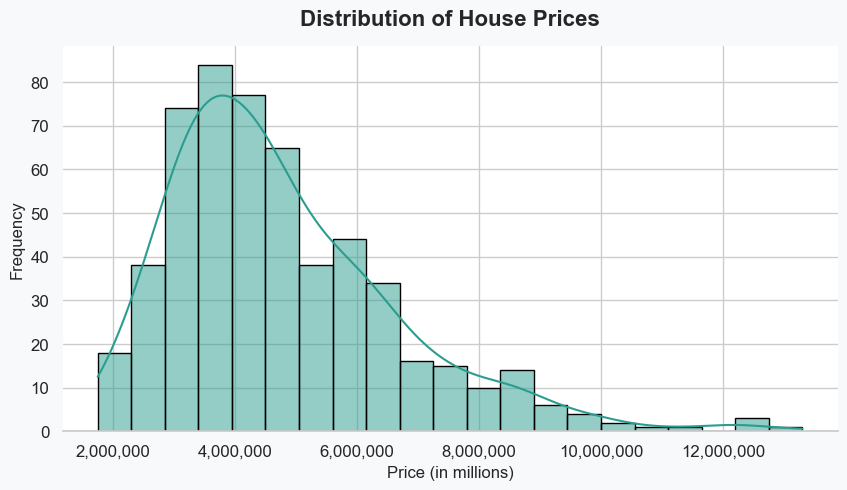

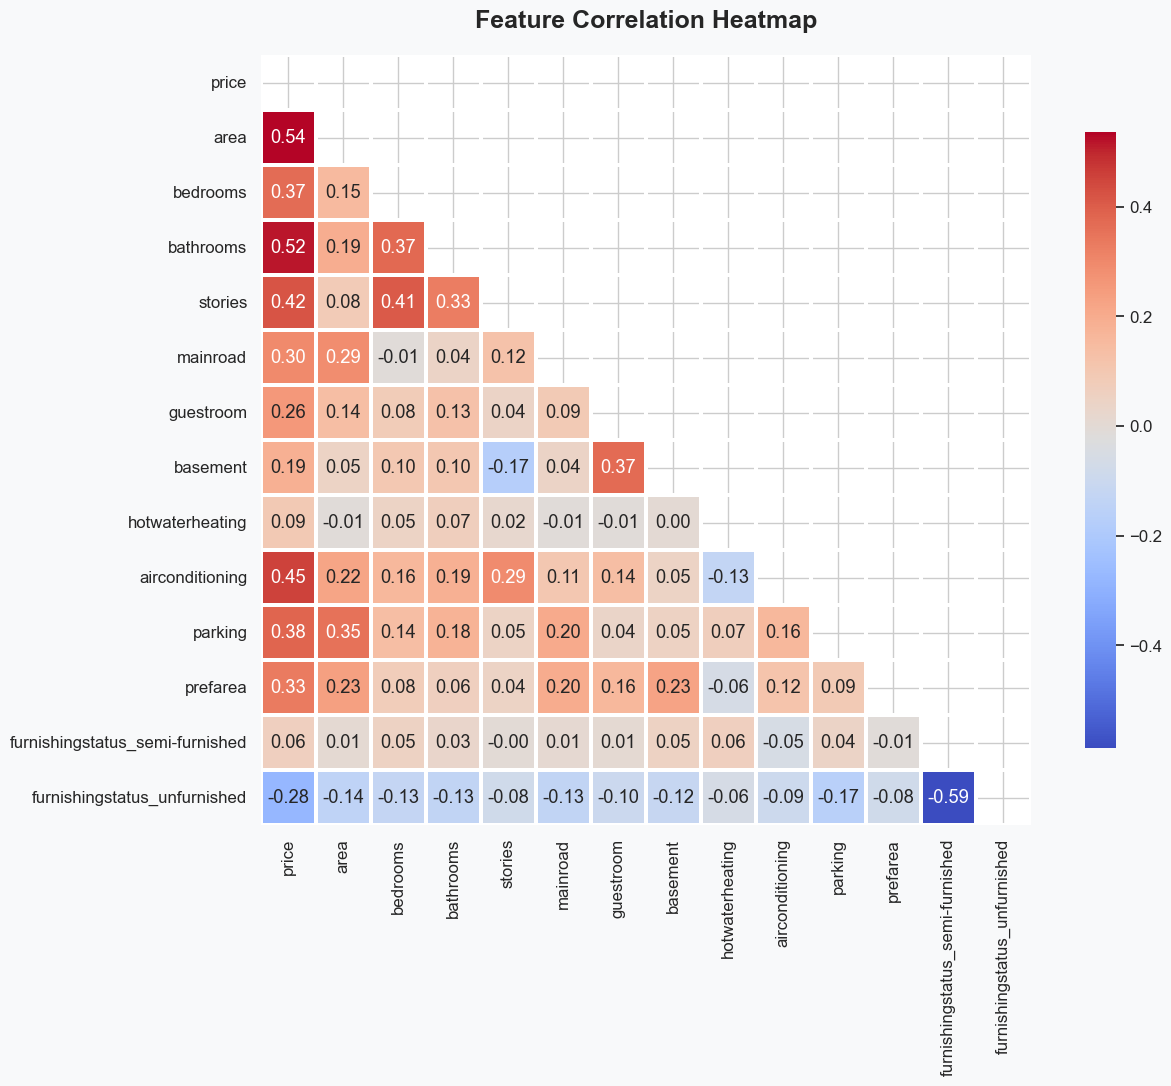

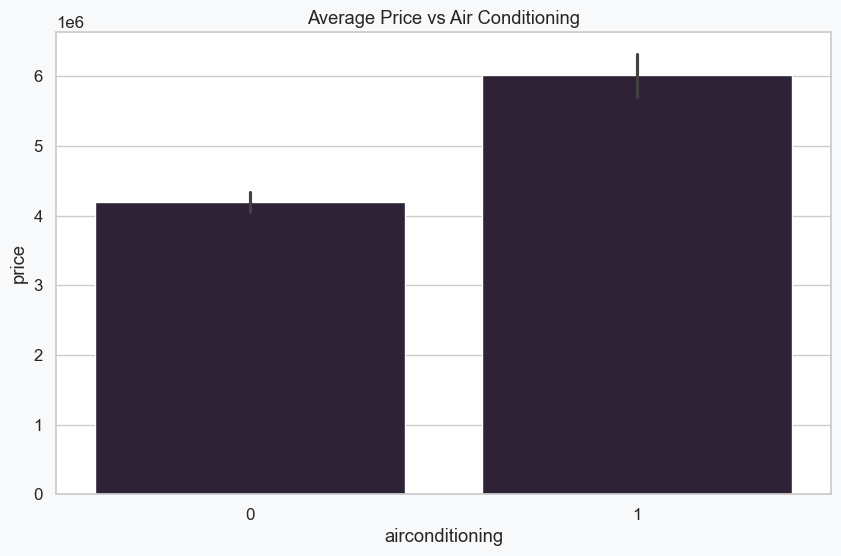


Top Features Correlated with Price:
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
Name: price, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="mako", font_scale=1.1)
plt.rcParams.update({'figure.facecolor': '#f8f9fa', 'axes.facecolor': '#ffffff'})

# Distribution of the target variable
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='#2a9d8f', ax=ax, edgecolor="black")
ax.set_title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Price (in millions)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
sns.despine(left=True)
plt.show()

# Correlation heatmap 
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=1.5, cbar_kws={"shrink": .8}, square=True)
plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.show()

# Bar plot for air conditioning vs price
plt.figure(figsize=(10, 6))
sns.barplot(x='airconditioning', y='price', data=df)
plt.title('Average Price vs Air Conditioning')
plt.show()

# Identify strongest positive correlations with price
print("\nTop Features Correlated with Price:")
print(correlation_matrix['price'].sort_values(ascending=False)[1:6])


## 3. Feature Scaling
Since some features have much larger values compared to other features, i made use of **min-max scaling** to continuous variables. This prevents scale discrepancies from making the linear model biased.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Features to scale continuous integers
continuous_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

df[continuous_cols] = scaler.fit_transform(df[continuous_cols])
display(df.head())


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,0.396564,0.6,0.333333,0.666667,1,0,0,0,1,0.666667,1,0,0
1,12250000,0.502405,0.6,1.000000,1.000000,1,0,0,0,1,1.000000,0,0,0
2,12250000,0.571134,0.4,0.333333,0.333333,1,0,1,0,0,0.666667,1,1,0
3,12215000,0.402062,0.6,0.333333,0.333333,1,0,1,0,1,1.000000,1,0,0
4,11410000,0.396564,0.6,0.000000,0.333333,1,1,1,0,1,0.666667,0,0,0


## 4. Model training - baseline model
Split the dataset into an 80\20 train test sections before starting the training.

I will fit a multiple linear legression model to address the more than 1 important attributes taking part in this prediction.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df.drop('price', axis=1)
y = df['price']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit multiple linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[3433346.11, 383893.51,3283334.36,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.228e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


## 5. Evaluation and refinement dashboard
Now to evaluate the baseline model and the refined intermediate model (**decision tree regressor** )- using visual dashboards to compare performance and feature importance.

Multiple Linear Regression - MAE: 970,043.40
Multiple Linear Regression - R-Squared: 0.6529

Decision tree regressor (max_depth=5) - MAE: 1,236,033.73
Decision tree regressor (max_depth=5) - R-Squared: 0.4602



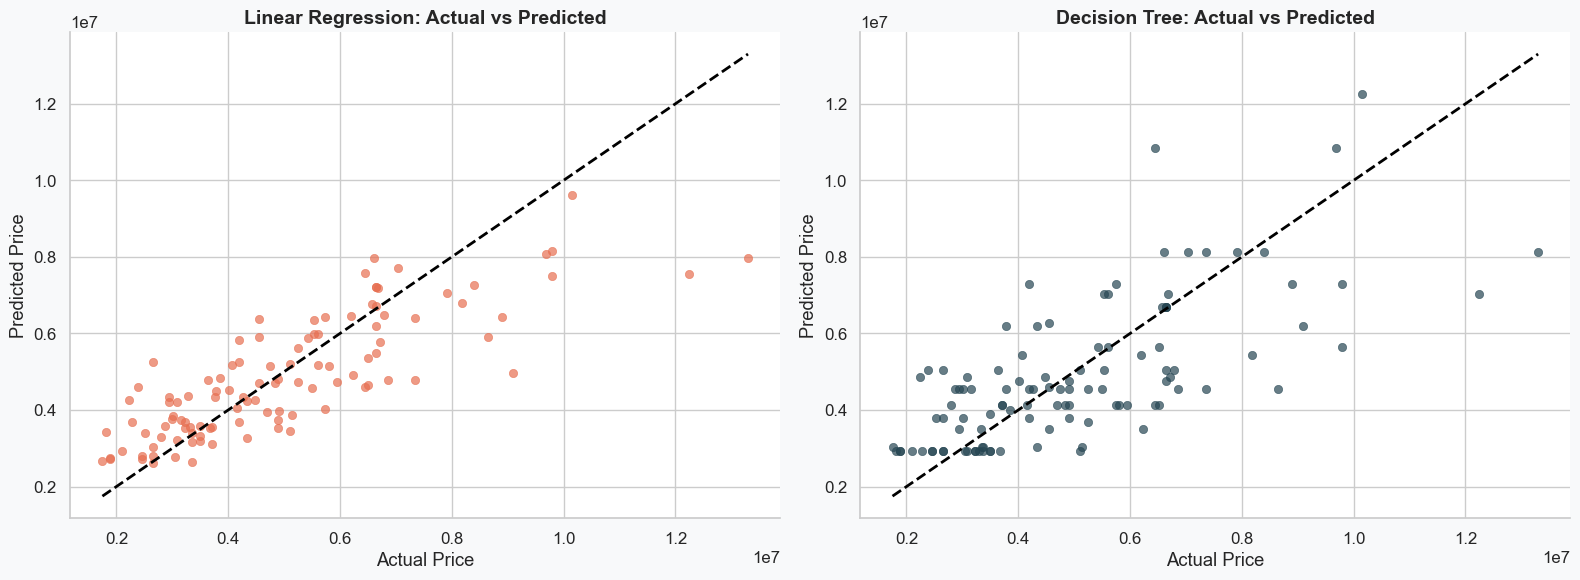

In [ ]:
# Evaluate baseline model
y_pred_lr = lr_model.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Multiple Linear Regression - MAE: {mae_lr:,.2f}")
print(f"Multiple Linear Regression - R-Squared: {r2_lr:.4f}\n")

from sklearn.tree import DecisionTreeRegressor

# Initialize and fit decision tree regressor 
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision tree regressor (max_depth=5) - MAE: {mae_dt:,.2f}")
print(f"Decision tree regressor (max_depth=5) - R-Squared: {r2_dt:.4f}\n")

# Model performance dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs predicted - linear Regression
sns.scatterplot(x=y_test, y=y_pred_lr, ax=axes[0], color="#e76f51", alpha=0.7, edgecolor=None)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# Actual vs predicted - decision tree regression
sns.scatterplot(x=y_test, y=y_pred_dt, ax=axes[1], color="#264653", alpha=0.7, edgecolor=None)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title('Decision Tree: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
sns.despine()
plt.show()


### Intermediate Model- feature importance
Decision Trees are prone to overfitting the training data if left unconstrained. This is prevented by tuning the model by setting max_depth=5. This limits the tree's growth, ensuring the model generalizes better to unseen test data rather than just memorizing the training set. We will also extract feature importance scores to communicate which property attributes most heavily influence the final price.

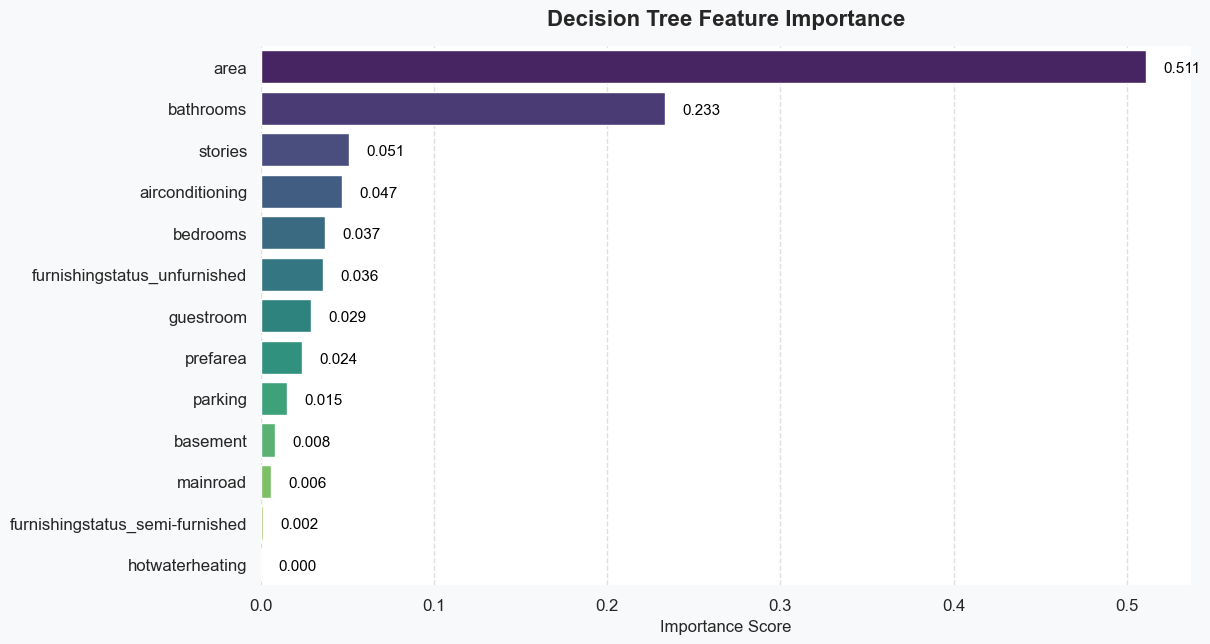

In [ ]:
# Extract feature importance scores
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Custom stylized barplot for feature importance
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')

# Add data labels to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(0.01 + width, p.get_y() + 0.55 * p.get_height(),
             f'{width:.3f}',
             ha='left', va='center', fontsize=11, color='black')

plt.title('Decision Tree Feature Importance', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('')
sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
plt.show()


## 6. Project Summary

In this ML project, we successfully developed and evaluated supervised machine learning models to predict residential property prices based on key housing attributes. 

**Model performance**
*   The **Baseline model - multiple linear regression** provided a strong foundational understanding of linear relationships within the data.
*   For capturing more complex, non-linear patterns, we introduced the **Intermediate model -Decision tree regressor**. By actively tuning the max_depth parameter to 5 and effectively constrained the model, acting as a safeguard against overfitting the training data and improving its ability to generalize to unseen properties.

**Feature importance**

By extracting the feature importance scores from decision trees, we identified the primary drivers of real estate valuation in this dataset: 

1. The total **square footage - area**,
2. The presence of **air conditioning** &
3. The **number of bathrooms** emerged as the most heavily weighted factors influencing final property prices. 
